# BTS Failure Prediction Project


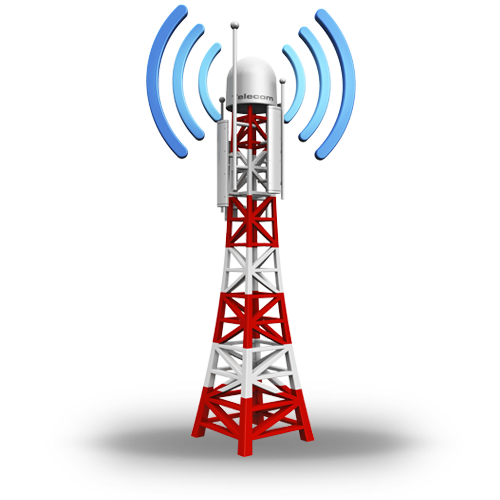


## Problem Statement

Predict whether a BTS (Base Transceiver Station) will experience a fault or failure based on network logs and performance indicators.

**Example target:**

Failure = 1
No Failure = 0

or

**Fault Severity:**

0 = Normal
1 = Minor Fault
2 = Major Fault

Datasets like the Telstra Network Disruptions are commonly used for this type of problem.

## Data Understanding

### Typical telecom BTS datasets contain:

| Feature       | Meaning        |
| ------------- | -------------- |
| location_id   | BTS site ID    |
| event_type    | Network event  |
| log_feature   | System log     |
| resource_type | Equipment used |
| severity_type | Fault level    |
| timestamp     | Event time     |


These features simulate network alarms generated by BTS equipment.

### Import Libraries

In [25]:

import pandas as pd
import numpy as np
import joblib


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

### Load the Dataset

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
event_type = pd.read_csv("event_type.csv")
log_feature = pd.read_csv("log_feature.csv")
resource_type = pd.read_csv("resource_type.csv")
severity_type = pd.read_csv("severity_type.csv")

check the data:

In [3]:
print(train.head())
print(train.shape)

      id      location  fault_severity
0  14121  location 118               1
1   9320   location 91               0
2  14394  location 152               1
3   8218  location 931               1
4  14804  location 120               0
(7381, 3)


### Merge All Dataset Tables

Many telecom datasets are split into multiple files.

In [4]:
df = train.merge(event_type, on="id", how="left")
df = df.merge(log_feature, on="id", how="left")
df = df.merge(resource_type, on="id", how="left")
df = df.merge(severity_type, on="id", how="left")

print(df.head())

      id      location  fault_severity     event_type  log_feature  volume  \
0  14121  location 118               1  event_type 34  feature 312      19   
1  14121  location 118               1  event_type 34  feature 232      19   
2  14121  location 118               1  event_type 35  feature 312      19   
3  14121  location 118               1  event_type 35  feature 232      19   
4   9320   location 91               0  event_type 34  feature 315     200   

     resource_type    severity_type  
0  resource_type 2  severity_type 2  
1  resource_type 2  severity_type 2  
2  resource_type 2  severity_type 2  
3  resource_type 2  severity_type 2  
4  resource_type 2  severity_type 2  


### Data Cleaning

Remove text from categorical values.

In [5]:
df['location'] = df['location'].str.replace('location ', '').astype(int)
df['event_type'] = df['event_type'].str.replace('event_type ', '').astype(int)
df['resource_type'] = df['resource_type'].str.replace('resource_type ', '').astype(int)
df['severity_type'] = df['severity_type'].str.replace('severity_type ', '').astype(int)
df['log_feature'] = df['log_feature'].str.replace('feature ', '').astype(int)

Check missing values:

In [6]:
df.isnull().sum()

id                0
location          0
fault_severity    0
event_type        0
log_feature       0
volume            0
resource_type     0
severity_type     0
dtype: int64

### Exploratory Data Analysis (EDA)

#### Fault severity distribution

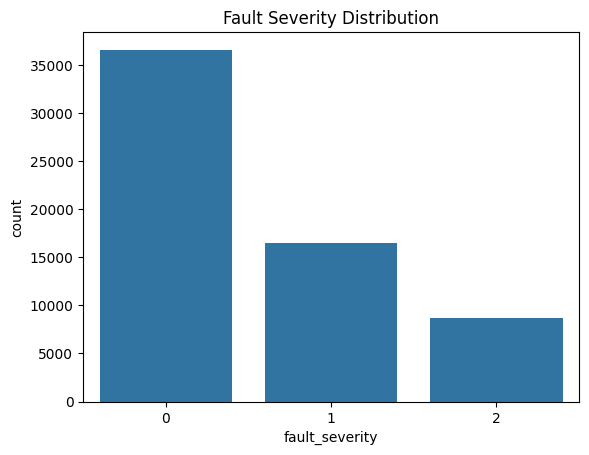

In [7]:
sns.countplot(x="fault_severity", data=df)
plt.title("Fault Severity Distribution")
plt.show()

#### Top locations with faults

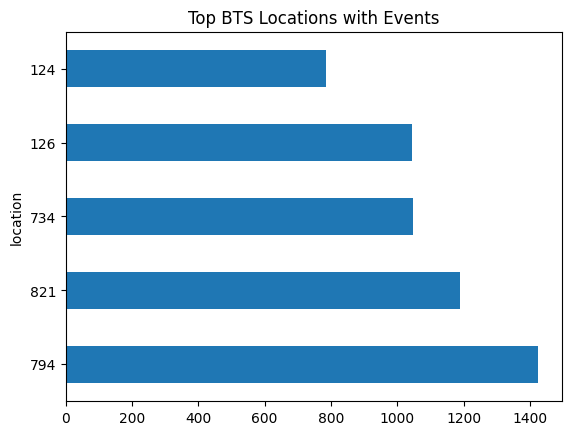

In [14]:
top_locations = df['location'].value_counts().head(5)
top_locations.plot(kind='barh')
plt.title("Top BTS Locations with Events")
plt.show()

### Feature Engineering

Aggregate logs per BTS id.

In [15]:
features = df.groupby("id").agg({
    "location":"first",
    "event_type":"count",
    "log_feature":"count",
    "resource_type":"count",
    "severity_type":"mean",
    "volume":"sum",
    "fault_severity":"first"
}).reset_index()

print(features.head())

   id  location  event_type  log_feature  resource_type  severity_type  \
0   1       601          12           12             12            1.0   
1   5       460           4            4              4            2.0   
2   6       332           2            2              2            2.0   
3   8       243          12           12             12            2.0   
4  13       418           4            4              4            2.0   

   volume  fault_severity  
0      20               1  
1      34               0  
2       2               1  
3      32               0  
4       4               0  


### Prepare Data for Machine Learning

Define features and target.

In [16]:
X = features.drop(["id","fault_severity"], axis=1)
y = features["fault_severity"]

Split dataset:

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Machine Learning Models

#### Logistic Regression

In [19]:
lr = LogisticRegression(max_iter=10000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6513202437373053


#### Random Forest (Better for this problem)

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6804333107650643


### Model Evaluation

#### Classification report:

In [21]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       960
           1       0.47      0.42      0.44       366
           2       0.52      0.47      0.49       151

    accuracy                           0.68      1477
   macro avg       0.59      0.57      0.58      1477
weighted avg       0.67      0.68      0.67      1477



#### Confusion matrix:

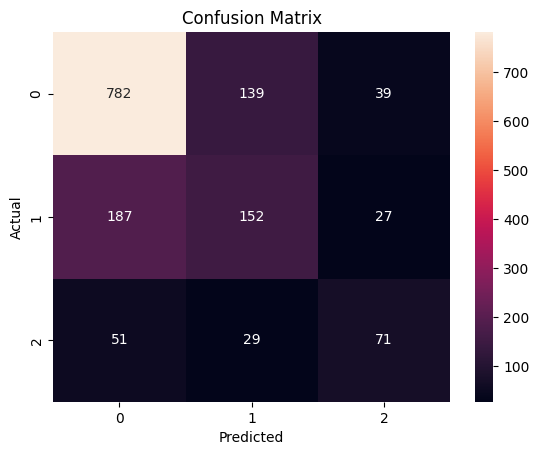

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Feature Importance (Very Useful for Telecom Analysis)

In [23]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

         Feature  Importance
0       location    0.535500
5         volume    0.279726
4  severity_type    0.057871
3  resource_type    0.043052
2    log_feature    0.041989
1     event_type    0.041863


Plot importance:

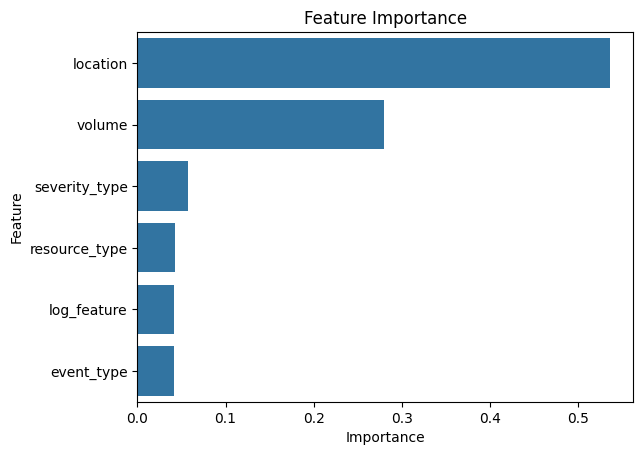

In [24]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

### Save the best model


In [26]:

joblib.dump(rf, "bts_failure_model.pkl")

['bts_failure_model.pkl']